In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

plt.style.use("ggplot")


In [2]:
file_path = "cs-training.csv"
data = pd.read_csv(file_path)

data.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

target = "SeriousDlqin2yrs"

print("\nDataset Shape:", data.shape)
display(data.head())



Dataset Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


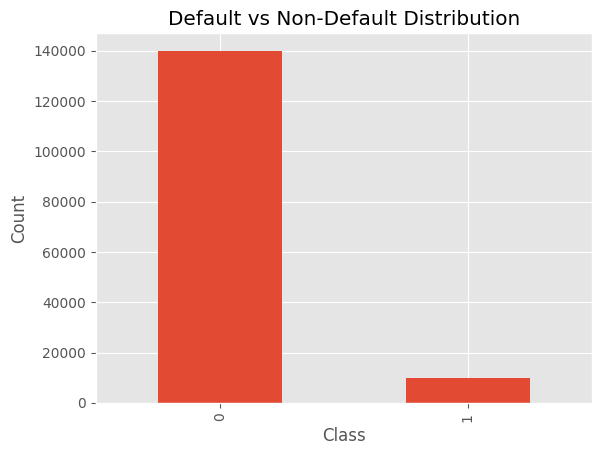

In [3]:
plt.figure()
data[target].value_counts().plot(kind='bar')
plt.title("Default vs Non-Default Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [4]:

data.fillna(data.median(numeric_only=True), inplace=True)

for col in data.select_dtypes(include=[np.number]).columns:
    lower = data[col].quantile(0.01)
    upper = data[col].quantile(0.99)
    data[col] = data[col].clip(lower, upper)

print("After Cleaning Shape:", data.shape)

After Cleaning Shape: (150000, 11)


In [5]:
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (112500, 10)
Test Shape : (37500, 10)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print("\nBefore SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_res.value_counts())


Before SMOTE:
 SeriousDlqin2yrs
0    104980
1      7520
Name: count, dtype: int64

After SMOTE:
 SeriousDlqin2yrs
0    104980
1    104980
Name: count, dtype: int64


In [8]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_res, y_train_res)

lr_preds = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_preds)

print("\nLogistic Regression AUC:", lr_auc)



Logistic Regression AUC: 0.8595357938683915


In [9]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)

rf_preds = rf.predict_proba(X_test_scaled)[:, 1]
rf_auc = roc_auc_score(y_test, rf_preds)

print("Random Forest AUC:", rf_auc)


Random Forest AUC: 0.8618859402234318


In [10]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_res, y_train_res)

xgb_preds = xgb.predict_proba(X_test_scaled)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_preds)

print("XGBoost AUC:", xgb_auc)


XGBoost AUC: 0.8497231209308668


In [11]:
def evaluate(name, y_true, y_prob):

    # Optimal threshold via Youden Index
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_thresh = thresholds[np.argmax(tpr - fpr)]

    y_pred = (y_prob >= best_thresh).astype(int)

    print(f"\n{name}")
    print("Best Threshold:", round(best_thresh,3))
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("AUC      :", roc_auc_score(y_true, y_prob))


evaluate("Logistic Regression", y_test, lr_preds)
evaluate("Random Forest", y_test, rf_preds)
evaluate("XGBoost", y_test, xgb_preds)


Logistic Regression
Best Threshold: 0.508
Accuracy : 0.8093066666666666
Precision: 0.22255405566837894
Recall   : 0.74341580207502
F1 Score : 0.3425576905396709
AUC      : 0.8595357938683915

Random Forest
Best Threshold: 0.437
Accuracy : 0.7765866666666666
Precision: 0.20253292806484297
Recall   : 0.7976855546687949
F1 Score : 0.3230446024563672
AUC      : 0.8618859402234318

XGBoost
Best Threshold: 0.774
Accuracy : 0.7724266666666667
Precision: 0.1954324979789814
Recall   : 0.7717478052673583
F1 Score : 0.3118851798097081
AUC      : 0.8497231209308668


In [12]:
total = lr_auc + rf_auc + xgb_auc

w_lr = lr_auc / total
w_rf = rf_auc / total
w_xgb = xgb_auc / total

ensemble_preds = (
    w_lr * lr_preds +
    w_rf * rf_preds +
    w_xgb * xgb_preds
)

overall_auc = roc_auc_score(y_test, ensemble_preds)

print("\n========== ENSEMBLE PERFORMANCE ==========")
print("Weights → LR:",round(w_lr,2)," RF:",round(w_rf,2)," XGB:",round(w_xgb,2))
print("Ensemble AUC:", overall_auc)


========== ENSEMBLE PERFORMANCE ==========
Weights → LR: 0.33  RF: 0.34  XGB: 0.33
Ensemble AUC: 0.8635692980043872


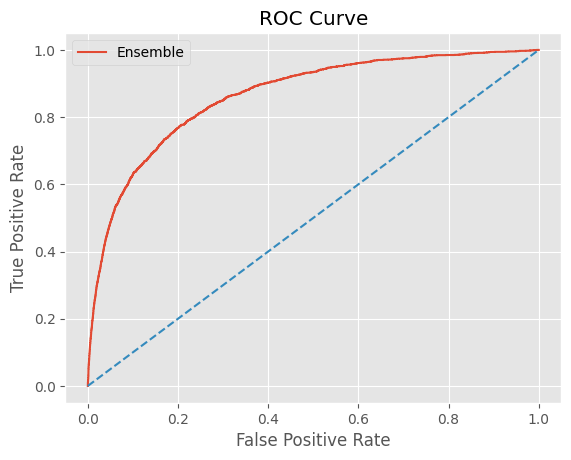

In [13]:
fpr, tpr, _ = roc_curve(y_test, ensemble_preds)

plt.figure()
plt.plot(fpr, tpr, label="Ensemble")
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

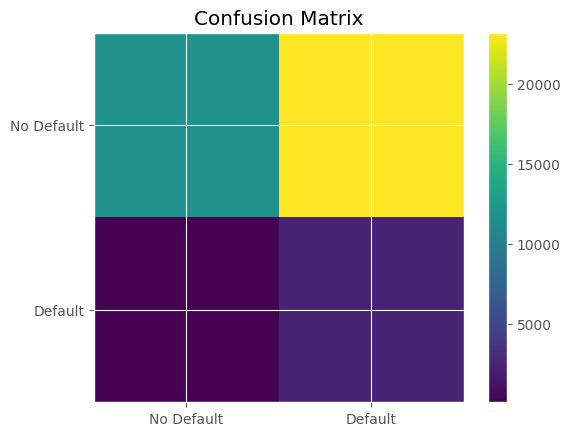

In [14]:
threshold = 0.35
y_pred = (xgb_preds >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks([0,1],["No Default","Default"])
plt.yticks([0,1],["No Default","Default"])
plt.colorbar()
plt.show()


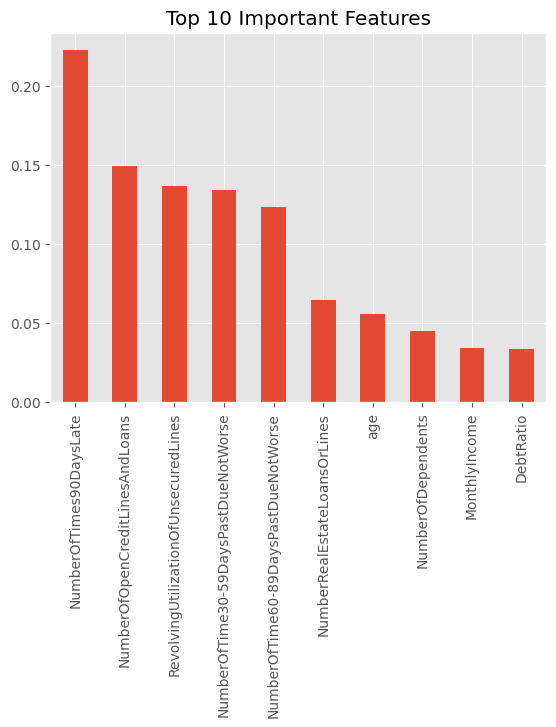

In [15]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.show()

In [16]:
def risk_tier(prob):
    if prob < 0.2:
        return "Low Risk"
    elif prob < 0.5:
        return "Medium Risk"
    else:
        return "High Risk"

risk_df = pd.DataFrame({
    "Probability_of_Default": xgb_preds,
    "Risk_Tier": [risk_tier(p) for p in xgb_preds]
})

In [17]:
decision_map = {
    "Low Risk": "Approve Loan",
    "Medium Risk": "Manual Review",
    "High Risk": "Reject Loan"
}

risk_df["Loan_Decision"] = risk_df["Risk_Tier"].map(decision_map)

print("\nLoan Decision Dashboard:")
display(risk_df.head(10))


Loan Decision Dashboard:


,Probability_of_Default,Risk_Tier,Loan_Decision
0,0.549983,High Risk,Reject Loan
1,0.338102,Medium Risk,Manual Review
2,0.421344,Medium Risk,Manual Review
3,0.153972,Low Risk,Approve Loan
4,0.448079,Medium Risk,Manual Review
5,0.884247,High Risk,Reject Loan
6,0.531119,High Risk,Reject Loan
7,0.046809,Low Risk,Approve Loan
8,0.837649,High Risk,Reject Loan
9,0.844199,High Risk,Reject Loan
